# 🎯 Feature Engineering & Modélisation
## Prédiction des Prix Immobiliers en Mauritanie

**Objectif** : Construire et évaluer plusieurs modèles de régression pour prédire le prix des biens immobiliers.

Ce notebook couvre :
1. 🔧 Feature Engineering complet
2. 📊 Préparation des données
3. 🤖 Test de 6 modèles différents
4. ✅ Validation croisée 5-fold
5. 💾 Sauvegarde du meilleur modèle

---

**Variable cible** : `prix` (en MRU - Ouguiya mauritanien)  
**Contexte** : Marché immobilier de Nouakchott

> 💡 *Projet Capstone - SupNum - Machine Learning Course - Mohamed*

## 🔧 Setup - Imports & Configuration

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, re
from datetime import datetime
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (train_test_split, cross_validate, KFold, 
                                      RandomizedSearchCV, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               StackingRegressor, VotingRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform
import joblib

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost non disponible - pip install xgboost")

# LightGBM
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️  LightGBM non disponible - pip install lightgbm")

# Configuration des graphiques
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Configuration des chemins
data_path = '../data/raw/kaggle_train.csv'
test_path = '../data/raw/kaggle_test.csv'
model_dir = Path('../model')

print("✅ Librairies chargées !")
print(f"   XGBoost : {'✅' if XGBOOST_AVAILABLE else '❌'}")
print(f"   LightGBM: {'✅' if LGBM_AVAILABLE else '❌'}")
print(f"📁 Chemin des données : {data_path}")
print(f"📁 Dossier modèles : {model_dir}")

⚠️  XGBoost non disponible - pip install xgboost
⚠️  LightGBM non disponible - pip install lightgbm
✅ Librairies chargées !
   XGBoost : ❌
   LightGBM: ❌
📁 Chemin des données : ../data/raw/kaggle_train.csv
📁 Dossier modèles : ../model


---
## 📥 Section 2 : Chargement des données

In [40]:
# Charger les données
df = pd.read_csv(data_path, encoding='utf-8')
print(f"📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📊 Colonnes disponibles :")
print(list(df.columns))
print(f"\n📋 Aperçu :")
df.head()

📐 Dimensions : 1153 lignes × 12 colonnes

📊 Colonnes disponibles :
['id', 'titre', 'prix', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication']

📋 Aperçu :


,id,titre,prix,surface_m2,nb_chambres,nb_salons,nb_sdb,quartier,description,caracteristiques,source,date_publication
0,1076,منزل احذ اللنكات حمام الياسمين,1800000.0,150.0,3.0,2.0,NaN,Arafat,دار للبيع اعل شارع اكبير احذ حمام الياسمين الل...,Titre foncier | 1 balcon(s) | Taille rue: 15.0...,voursa.com,2025-09-13
1,875,فرصة دار مكونه من طابقين ارضي و واحد فوقوني كا...,1800000.0,300.0,6.0,3.0,NaN,Tevragh Zeina,فرصة دار ، الطابق الأرضي يحتاج ترميم بسبب المل...,1 balcon(s) | Taille rue: N/A | Proche de: كرف...,voursa.com,2025-07-06
2,453,دار فتيارت فاتح فبرك,900000.0,216.0,1.0,1.0,NaN,Teyarett,سعر 9ملايين مدخله 50الف حد شاري ول عندو طلب تل...,Titre foncier | type de propriété: Autre | 1 b...,voursa.com,2026-01-20
3,987,دار للبيـــــــــــــــــــــع أفي عين الطلح,1600000.0,150.0,3.0,1.0,2.0,Teyarett,السلام عليكم ذاك دار للبيـــــــــــــــــــــ...,NaN,voursa.com,2025-12-09
4,252,ملح سكتير 2,800000.0,180.0,3.0,2.0,NaN,Toujounine,السلام عليكم \nفرصة للبيـــــــــــــــــــــع...,Titre foncier | 1 balcon(s) | Taille rue: 25.0...,voursa.com,2025-04-18


In [41]:
# Vérifier les valeurs manquantes
print("🔍 Valeurs manquantes :")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'N_Missing': missing, 'Pct_Missing': missing_pct})
missing_df = missing_df.query('N_Missing > 0').sort_values('Pct_Missing', ascending=False)
if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ Aucune valeur manquante")

🔍 Valeurs manquantes :


,N_Missing,Pct_Missing
nb_sdb,833,72.25
caracteristiques,157,13.62
nb_chambres,14,1.21


---
## 🔧 Section 3 : Feature Engineering Complet

### 3.1 Fonction de Feature Engineering complète (V2 améliorée)

> **Stratégie** : Créer une fonction réutilisable pour appliquer le même traitement au train ET au test.
> 
> Features extraites :
> - **Numériques brutes** : surface_m2, nb_chambres, nb_salons, nb_sdb
> - **Extraites de `caracteristiques`** : taille_rue, nb_balcons, type_propriete, has_garage, has_titre_foncier, has_camera, has_meuble, has_piscine, has_climatisation, has_ascenseur, has_jardin, has_terrasse, has_cuisine_equipee, nb_total_carac, nb_proche
> - **Score de standing** : somme des équipements premium (garage, caméra, piscine, clim, ascenseur, etc.)
> - **Ratios & interactions** : surface_per_piece, surface_per_chambre, surface_per_room, surface×chambres, surface×standing, surface×quartier, log_surface, surface², sqrt_surface, etc.
> - **Étages** : nb_etages (extrait du texte arabe/français), surface_per_etage
> - **Bins de surface** : catégories petit/moyen/grand/très grand
> - **Textuelles** : titre_len, desc_len, desc_word_count, is_luxe, is_neuf, is_renove, has_vue
> - **Temporelles** : age_annonce, mois_publication, trimestre
> - **Quartier** : One-hot encoding (vecteurs binaires par quartier)
> - **Source** : One-hot encoding de la source d'annonce

In [42]:
# ════════════════════════════════════════════════════════
#  FONCTION DE FEATURE ENGINEERING COMPLÈTE (V2 AMÉLIORÉE)
# ════════════════════════════════════════════════════════

def extract_taille_rue(s):
    """Extraire la largeur de la rue depuis `caracteristiques`"""
    if pd.isna(s): return np.nan
    m = re.search(r'Taille rue:\s*([\d.]+)', str(s))
    if m:
        val = float(m.group(1))
        return val if 0 < val <= 100 else np.nan
    return np.nan

def extract_nb_balcons(s):
    """Extraire le nombre de balcons"""
    if pd.isna(s): return 0
    m = re.search(r'(\d+)\s*balcon', str(s))
    val = int(m.group(1)) if m else 0
    return val if val <= 10 else 0

def extract_type_propriete(s):
    """Extraire le type de propriété"""
    if pd.isna(s): return 'Inconnu'
    m = re.search(r'type de propriété:\s*([^|]+)', str(s))
    return m.group(1).strip() if m else 'Inconnu'

def extract_nb_etages(s):
    """Extraire le nombre d'étages depuis description/titre"""
    if pd.isna(s): return 1
    s = str(s).lower()
    # Chercher patterns comme "2 étages", "طابقين" (2 étages en arabe), "3 طوابق"
    m = re.search(r'(\d+)\s*[ée]tage', s)
    if m: return int(m.group(1))
    if 'طابقين' in s or 'طابقان' in s: return 2
    m = re.search(r'(\d+)\s*طوابق', s)
    if m: return int(m.group(1))
    m = re.search(r'(\d+)\s*طابق', s)
    if m: return int(m.group(1))
    return 1

def extract_proche_count(s):
    """Compter le nombre de lieux proches mentionnés"""
    if pd.isna(s): return 0
    matches = re.findall(r'Proche de:', str(s))
    return len(matches)


def build_features(df, date_ref=None, quartier_categories=None, medians=None):
    """
    Fonction principale de Feature Engineering (V2 améliorée).
    
    Args:
        df: DataFrame source
        date_ref: date de référence pour age_annonce (None = calculer depuis le train)
        quartier_categories: liste des quartiers vus en train (None = calculer depuis les données)
        medians: dict avec les médianes du train pour l'imputation
    
    Returns:
        df_feat: DataFrame avec features sélectionnées
        date_ref: date de référence utilisée
        quartier_categories: liste des quartiers (pour réutilisation sur test)
        medians: médianes utilisées
    """
    df_feat = df.copy()
    
    # ── 1. Standardiser quartier ──
    quartier_mapping = {
        'Riyadh': 'Riyad', 'Tevragh-Zeina': 'Tevragh Zeina',
        'TevraghZeina': 'Tevragh Zeina',
    }
    df_feat['quartier'] = df_feat['quartier'].replace(quartier_mapping).str.title()
    
    # ── 2. Imputer les valeurs manquantes ──
    if medians is None:
        medians = {}
        for col in ['nb_chambres', 'nb_salons', 'surface_m2']:
            medians[col] = df_feat[col].median()
    
    for col in ['nb_chambres', 'nb_salons', 'surface_m2']:
        df_feat[col] = df_feat[col].fillna(medians.get(col, 0))
    df_feat['nb_sdb'] = df_feat['nb_sdb'].fillna(0)
    
    
    # ── 4. Extraire depuis `caracteristiques` ──
    carac = df_feat['caracteristiques'].fillna('')
    carac_lower = carac.str.lower()
    all_text_lower = carac_lower + ' ' + df_feat['description'].fillna('').str.lower()
    
    # Numériques
    df_feat['taille_rue'] = df_feat['caracteristiques'].apply(extract_taille_rue)
    taille_med = medians.get('taille_rue', df_feat['taille_rue'].median())
    medians['taille_rue'] = taille_med
    df_feat['taille_rue'] = df_feat['taille_rue'].fillna(taille_med)
    
    df_feat['nb_balcons'] = df_feat['caracteristiques'].apply(extract_nb_balcons)
    
    # ── Booléens demandés ──
    df_feat['has_piscine'] = all_text_lower.str.contains('piscine|مسبح', regex=True).astype(int)
    df_feat['has_garage'] = carac_lower.str.contains('garage').astype(int)
    df_feat['has_clim'] = all_text_lower.str.contains('climatisation|clim|تكييف|مكيف', regex=True).astype(int)
    
    # ── 5. Features temporelles ──
    if 'date_publication' in df_feat.columns:
        df_feat['date_publication'] = pd.to_datetime(df_feat['date_publication'], errors='coerce')
        if date_ref is None:
            date_ref = df_feat['date_publication'].max()
        df_feat['age_annonce'] = (date_ref - df_feat['date_publication']).dt.days
        df_feat['age_annonce'] = df_feat['age_annonce'].fillna(df_feat['age_annonce'].median()).clip(lower=0)
    else:
        df_feat['age_annonce'] = 0  # Valeur par défaut si pas de date
    
    # ── 6. Features de ratio et interaction ──
    df_feat['nb_pieces_total'] = df_feat['nb_chambres'] + df_feat['nb_salons']
    df_feat['total_rooms'] = df_feat['nb_chambres'] + df_feat['nb_salons'] + df_feat['nb_sdb']
    df_feat['surface_per_piece'] = df_feat['surface_m2'] / (df_feat['nb_pieces_total'] + 1)
    df_feat['surface_per_chambre'] = df_feat['surface_m2'] / (df_feat['nb_chambres'] + 1)
    df_feat['surface_x_chambres'] = df_feat['surface_m2'] * df_feat['nb_chambres']
    df_feat['surface_x_taille_rue'] = df_feat['surface_m2'] * df_feat['taille_rue']
    
    # ── Nombre d'étages ──
    desc_titre = df_feat['titre'].fillna('') + ' ' + df_feat['description'].fillna('')
    df_feat['nb_etages'] = desc_titre.apply(extract_nb_etages)
    df_feat['surface_per_etage'] = df_feat['surface_m2'] / (df_feat['nb_etages'] + 0.1)
    
    # ── Transformations non-linéaires ──
    df_feat['log_surface'] = np.log1p(df_feat['surface_m2'])
    df_feat['surface_sq'] = df_feat['surface_m2'] ** 2
    df_feat['sqrt_surface'] = np.sqrt(df_feat['surface_m2'])
    df_feat['log_taille_rue'] = np.log1p(df_feat['taille_rue'])
    
    # ── Bins de surface ──
    df_feat['surface_cat_tres_grand'] = (df_feat['surface_m2'] >= 400).astype(int)
    
    # ── 7. One-Hot Encoding quartier (vecteurs binaires) ──
    if quartier_categories is None:
        quartier_categories = sorted(df_feat['quartier'].dropna().unique().tolist())
    
    for q in quartier_categories:
        col_name = f'quartier_{q.replace(" ", "_")}'
        df_feat[col_name] = (df_feat['quartier'] == q).astype(int)
    
    quartier_dummy_cols = [f'quartier_{q.replace(" ", "_")}' for q in quartier_categories]
    
    # ── Sélectionner les features (avec one-hot quartier) ──
    selected_features = [
        'surface_m2',           
        'nb_chambres',          
        'nb_salons',            
        'nb_sdb',               
        'nb_pieces_total',      
        'has_piscine',          
        'has_garage',           
        'has_clim',             
        'age_annonce',          
        'taille_rue',           
        'nb_balcons',           
        'total_rooms',          
        'surface_per_piece',   
        'surface_per_chambre',  
        'surface_x_chambres',   
        'surface_x_taille_rue', 
        'nb_etages',            
        'surface_per_etage',    
        'log_surface',          
        'surface_sq',           
        'sqrt_surface',        
        'log_taille_rue',       
        'surface_cat_tres_grand'
    ] + quartier_dummy_cols
    
    # Garder les colonnes originales nécessaires + les 30 features
    keep_cols = ['id', 'titre', 'description', 'caracteristiques', 'date_publication', 
                 'prix', 'source', 'quartier'] + selected_features
    # Filtrer pour ne garder que les colonnes qui existent
    keep_cols = [col for col in keep_cols if col in df_feat.columns]
    df_feat = df_feat[keep_cols]
    
    return df_feat, date_ref, quartier_categories, medians

print("✅ Fonction build_features() V2 définie — avec one-hot encoding quartier")

✅ Fonction build_features() V2 définie — avec one-hot encoding quartier


In [43]:
# ════════════════════════════════════════════════════════
#  APPLIQUER LE FEATURE ENGINEERING SUR LE TRAIN
# ════════════════════════════════════════════════════════
print("🔧 Application du Feature Engineering sur le dataset train...")

df_feat, date_ref, quartier_categories, medians = build_features(df)

print(f"\n📐 Dimensions après feature engineering : {df_feat.shape}")
print(f"📅 Date de référence : {date_ref}")

# Afficher les features créées
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"\n📊 {len(new_cols)} nouvelles colonnes créées :")
for col in new_cols:
    print(f"  ✅ {col}")

# Statistiques des features clés
print(f"\n📊 Features booléennes :")
bool_feats = ['has_piscine', 'has_garage', 'has_clim']
for f in bool_feats:
    if f in df_feat.columns:
        print(f"  {f}: {df_feat[f].sum()} ({df_feat[f].mean()*100:.1f}%)")

print(f"\n📊 One-Hot Encoding quartier ({len(quartier_categories)} quartiers) :")
quartier_cols = [c for c in df_feat.columns if c.startswith('quartier_') and c != 'quartier']
print(f"   Colonnes : {quartier_cols}")

🔧 Application du Feature Engineering sur le dataset train...

📐 Dimensions après feature engineering : (1153, 39)
📅 Date de référence : 2026-03-02 00:00:00

📊 27 nouvelles colonnes créées :
  ✅ nb_pieces_total
  ✅ has_piscine
  ✅ has_garage
  ✅ has_clim
  ✅ age_annonce
  ✅ taille_rue
  ✅ nb_balcons
  ✅ total_rooms
  ✅ surface_per_piece
  ✅ surface_per_chambre
  ✅ surface_x_chambres
  ✅ surface_x_taille_rue
  ✅ nb_etages
  ✅ surface_per_etage
  ✅ log_surface
  ✅ surface_sq
  ✅ sqrt_surface
  ✅ log_taille_rue
  ✅ surface_cat_tres_grand
  ✅ quartier_Arafat
  ✅ quartier_Dar_Naim
  ✅ quartier_Ksar
  ✅ quartier_Riyad
  ✅ quartier_Sebkha
  ✅ quartier_Tevragh_Zeina
  ✅ quartier_Teyarett
  ✅ quartier_Toujounine

📊 Features booléennes :
  has_piscine: 2 (0.2%)
  has_garage: 472 (40.9%)
  has_clim: 1 (0.1%)

📊 One-Hot Encoding quartier (8 quartiers) :
   Colonnes : ['quartier_Arafat', 'quartier_Dar_Naim', 'quartier_Ksar', 'quartier_Riyad', 'quartier_Sebkha', 'quartier_Tevragh_Zeina', 'quartier_Te

### 3.2 Nettoyage des outliers + Sélection des features

> **Stratégie** : 
> - **Suppression des outliers** : IQR sur log(prix) + filtrage des surfaces extrêmes
> - Prédire `log(prix)` au lieu de `prix` → distribution plus symétrique
> - Exclure les colonnes textuelles brutes et garder uniquement les features numériques/booléennes

In [44]:
# ════════════════════════════════════════════════════════
#  TRAITEMENT DES OUTLIERS + SÉLECTION DES FEATURES
# ════════════════════════════════════════════════════════

print("🔍 Détection et suppression des outliers...")

# --- Outlier removal basé sur IQR du log(prix) ---
log_prix = np.log1p(df_feat['prix'])
Q1 = log_prix.quantile(0.01)
Q3 = log_prix.quantile(0.99)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask_prix = (log_prix >= lower_bound) & (log_prix <= upper_bound)

# Outliers de surface aussi
mask_surface = (df_feat['surface_m2'] > 0) & (df_feat['surface_m2'] <= df_feat['surface_m2'].quantile(0.99))

mask = mask_prix & mask_surface
n_removed = (~mask).sum()
df_clean = df_feat[mask].copy().reset_index(drop=True)
print(f"   Supprimés : {n_removed} outliers ({n_removed/len(df_feat)*100:.1f}%)")
print(f"   Restants  : {len(df_clean)} lignes")

# --- Sélection des features ---
exclude_cols = ['id', 'titre', 'description', 'caracteristiques', 'date_publication',
                'prix', 'source', 'quartier', 'type_propriete']

feature_cols = [col for col in df_clean.columns 
                if col not in exclude_cols 
                and df_clean[col].dtype in ['int64', 'float64', 'int32', 'float32', 'bool', 'uint8']]

# Supprimer les features à variance nulle (ex: has_piscine si aucune piscine)
zero_var_cols = [col for col in feature_cols if df_clean[col].std() == 0]
if zero_var_cols:
    print(f"\n⚠️  Suppression de {len(zero_var_cols)} features à variance nulle : {zero_var_cols}")
    feature_cols = [col for col in feature_cols if col not in zero_var_cols]

print(f"\n📊 {len(feature_cols)} features sélectionnées :")
for i, col in enumerate(feature_cols):
    corr = df_clean[col].corr(df_clean['prix'])
    print(f"  {i+1:2d}. {col:30s} (corr={corr:+.4f})")

# Préparer X et y
X = df_clean[feature_cols].copy()

# ═══ Prédire log(prix) ═══
y_raw = df_clean['prix'].copy()
y = np.log1p(y_raw)

print(f"\n📐 Données (après nettoyage) :")
print(f"   X : {X.shape}")
print(f"   y : {y.shape}")
print(f"   y (log_prix) : mean={y.mean():.2f}, std={y.std():.2f}, skew={y.skew():.2f}")
print(f"   prix min : {y_raw.min():,.0f} MRU | max : {y_raw.max():,.0f} MRU")

# Vérifier les NaN
nan_count = X.isnull().sum().sum()
if nan_count > 0:
    print(f"\n⚠️  {nan_count} NaN restants — imputation par médiane...")
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    print("✅ NaN imputés")

# Remplacer les infinis
X = X.replace([np.inf, -np.inf], 0)

🔍 Détection et suppression des outliers...
   Supprimés : 11 outliers (1.0%)
   Restants  : 1142 lignes

📊 31 features sélectionnées :
   1. surface_m2                     (corr=+0.5287)
   2. nb_chambres                    (corr=+0.2989)
   3. nb_salons                      (corr=+0.2400)
   4. nb_sdb                         (corr=+0.0248)
   5. nb_pieces_total                (corr=+0.3209)
   6. has_piscine                    (corr=+0.1219)
   7. has_garage                     (corr=+0.0731)
   8. has_clim                       (corr=-0.0026)
   9. age_annonce                    (corr=+0.0193)
  10. taille_rue                     (corr=+0.1844)
  11. nb_balcons                     (corr=+0.1705)
  12. total_rooms                    (corr=+0.3020)
  13. surface_per_piece              (corr=+0.1208)
  14. surface_per_chambre            (corr=+0.1541)
  15. surface_x_chambres             (corr=+0.5200)
  16. surface_x_taille_rue           (corr=+0.5068)
  17. nb_etages                  

### 3.3 Split Train/Test et Normalisation

In [45]:
# ════════════════════════════════════════════════════════
#  SPLIT TRAIN/TEST ET NORMALISATION
# ════════════════════════════════════════════════════════

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_raw = np.expm1(y_train)  # Prix bruts pour évaluation
y_test_raw = np.expm1(y_test)

# Sauvegarder les noms des features
feature_names = list(X.columns)

print(f"📊 Split Train/Test :")
print(f"   Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features : {len(feature_names)}")
# show the first row of x_train
print(X_train.columns)

print(X_train.info())
# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ StandardScaler appliqué (fit sur train, transform sur test)")
print(f"   ⚠️  Pas de data leakage !")

📊 Split Train/Test :
   Train : 913 lignes (80%)
   Test  : 229 lignes (20%)
   Features : 31
Index(['surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'nb_pieces_total',
       'has_piscine', 'has_garage', 'has_clim', 'age_annonce', 'taille_rue',
       'nb_balcons', 'total_rooms', 'surface_per_piece', 'surface_per_chambre',
       'surface_x_chambres', 'surface_x_taille_rue', 'nb_etages',
       'surface_per_etage', 'log_surface', 'surface_sq', 'sqrt_surface',
       'log_taille_rue', 'surface_cat_tres_grand', 'quartier_Arafat',
       'quartier_Dar_Naim', 'quartier_Ksar', 'quartier_Riyad',
       'quartier_Sebkha', 'quartier_Tevragh_Zeina', 'quartier_Teyarett',
       'quartier_Toujounine'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 913 entries, 12 to 1126
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   surface_m2              913 non-null    float64
 1   nb_chambres          

---
## 🤖 Section 4 : Modélisation — Validation croisée

> **Stratégie** : Tester 7+ modèles avec prédiction de `log(prix)`, puis convertir en prix réel pour évaluation.

In [46]:
# ════════════════════════════════════════════════════════
#  DÉFINITION DES MODÈLES (V2 — Anti-overfitting)
# ════════════════════════════════════════════════════════

models = {
    # ── Baseline ──
    'Linear Regression': LinearRegression(),
    
    # ── Modèles linéaires régularisés ──
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    
    # ── Ensemble : Bagging ──
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=10, min_samples_split=10,
        min_samples_leaf=5, max_features=0.6, random_state=42, n_jobs=1
    ),
    
    # ── Ensemble : Boosting ──
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_split=10, min_samples_leaf=5,
        max_features=0.7, random_state=42
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=500, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=0.5,
        reg_lambda=2.0, min_child_weight=5, gamma=0.1,
        random_state=42, n_jobs=1, verbosity=0
    )

if LGBM_AVAILABLE:
    models['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=0.5,
        reg_lambda=2.0, num_leaves=31, min_child_samples=20,
        random_state=42, n_jobs=1, verbose=-1
    )

print(f"📊 {len(models)} modèles à tester :")
for name in models.keys():
    print(f"   - {name}")

📊 5 modèles à tester :
   - Linear Regression
   - Ridge
   - Lasso
   - Random Forest
   - Gradient Boosting


In [47]:
# ════════════════════════════════════════════════════════
#  VALIDATION CROISÉE 5-FOLD — RMSE, MAE, R²
# ════════════════════════════════════════════════════════

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

print("🔄 Validation croisée 5-fold — Métriques : RMSE, MAE, R²")
print("=" * 80)

results = {}

for name, model in models.items():
    print(f"\n📊 {name}...")
    
    cv_results = cross_validate(
        model, X_train_scaled, y_train,
        cv=kfold, scoring=scoring,
        return_train_score=True, n_jobs=1
    )
    
    # Métriques sur log(prix)
    rmse_cv = np.sqrt(-cv_results['test_neg_mse'])
    mae_cv = -cv_results['test_neg_mae']
    r2_cv = cv_results['test_r2']
    train_r2 = cv_results['train_r2']
    
    results[name] = {
        'RMSE': rmse_cv.mean(),
        'RMSE_std': rmse_cv.std(),
        'MAE': mae_cv.mean(),
        'MAE_std': mae_cv.std(),
        'R2': r2_cv.mean(),
        'R2_std': r2_cv.std(),
        'Train_R2': train_r2.mean(),
        'Overfit': train_r2.mean() - r2_cv.mean(),
    }
    
    print(f"   R²       : {r2_cv.mean():.4f} ± {r2_cv.std():.4f}")
    print(f"   RMSE     : {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")
    print(f"   MAE      : {mae_cv.mean():.4f} ± {mae_cv.std():.4f}")
    print(f"   Train R² : {train_r2.mean():.4f} | Overfit gap: {train_r2.mean() - r2_cv.mean():.4f}")

print("\n✅ Validation croisée terminée !")

🔄 Validation croisée 5-fold — Métriques : RMSE, MAE, R²

📊 Linear Regression...
   R²       : 0.4630 ± 0.1264
   RMSE     : 0.7113 ± 0.1064
   MAE      : 0.4796 ± 0.0433
   Train R² : 0.5668 | Overfit gap: 0.1039

📊 Ridge...
   R²       : 0.5107 ± 0.0835
   RMSE     : 0.6787 ± 0.0557
   MAE      : 0.4702 ± 0.0353
   Train R² : 0.5589 | Overfit gap: 0.0482

📊 Lasso...
   R²       : 0.5076 ± 0.0831
   RMSE     : 0.6809 ± 0.0569
   MAE      : 0.4718 ± 0.0353
   Train R² : 0.5606 | Overfit gap: 0.0529

📊 Random Forest...
   R²       : 0.5262 ± 0.0730
   RMSE     : 0.6675 ± 0.0384
   MAE      : 0.4694 ± 0.0204
   Train R² : 0.7294 | Overfit gap: 0.2032

📊 Gradient Boosting...
   R²       : 0.5167 ± 0.0841
   RMSE     : 0.6738 ± 0.0502
   MAE      : 0.4716 ± 0.0272
   Train R² : 0.8584 | Overfit gap: 0.3417

✅ Validation croisée terminée !


📊 Tableau comparatif — Validation croisée 5-fold :


,R2,R2_std,RMSE,RMSE_std,MAE,MAE_std,Train_R2,Overfit
Random Forest,0.5262,0.0730,0.6675,0.0384,0.4694,0.0204,0.7294,0.2032
Gradient Boosting,0.5167,0.0841,0.6738,0.0502,0.4716,0.0272,0.8584,0.3417
Ridge,0.5107,0.0835,0.6787,0.0557,0.4702,0.0353,0.5589,0.0482
Lasso,0.5076,0.0831,0.6809,0.0569,0.4718,0.0353,0.5606,0.0529
Linear Regression,0.4630,0.1264,0.7113,0.1064,0.4796,0.0433,0.5668,0.1039


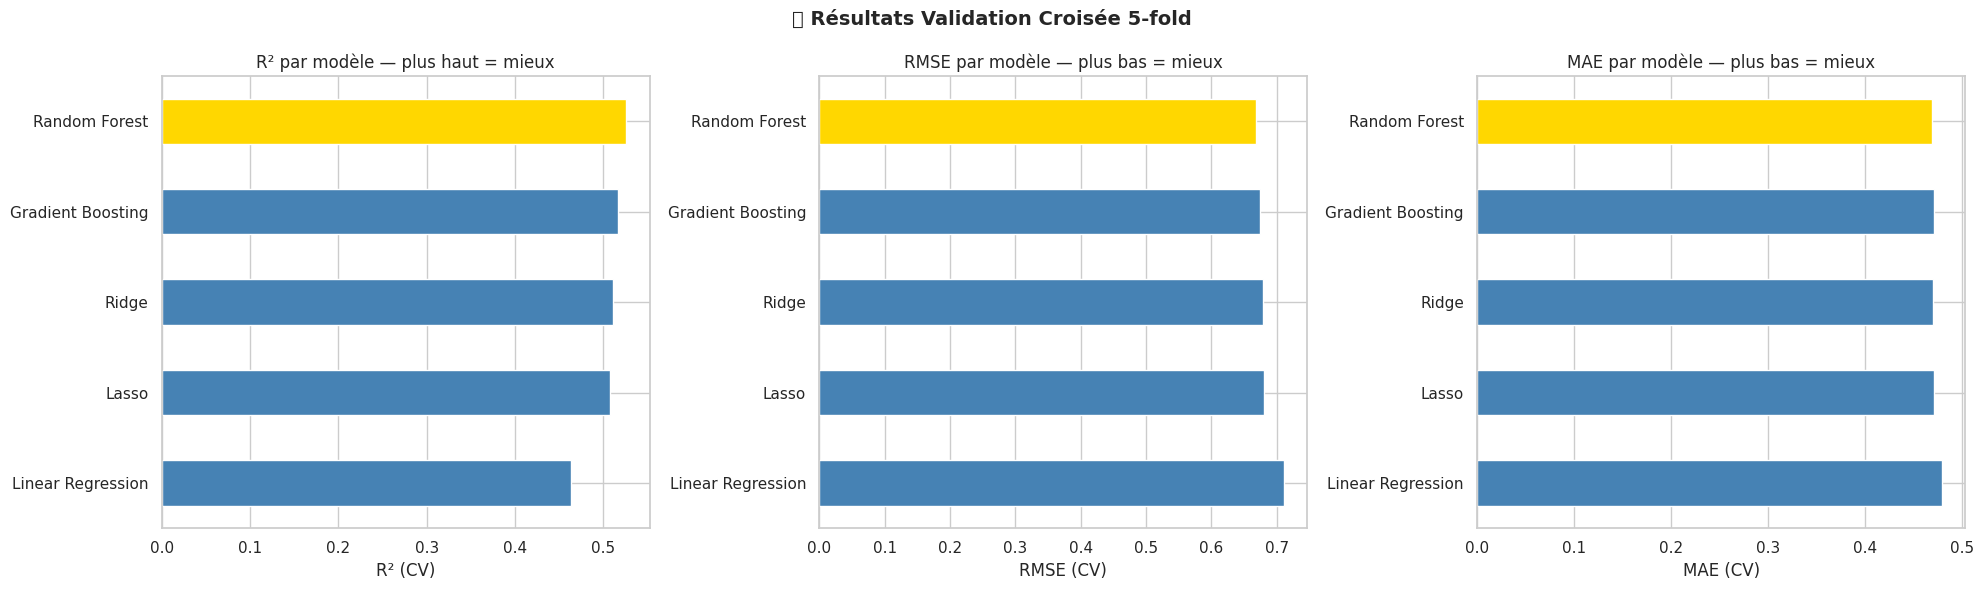


🏆 Meilleur modèle (CV) : Random Forest avec R²=0.5262


In [48]:
# ════════════════════════════════════════════════════════
#  TABLEAU COMPARATIF DES RÉSULTATS (CV 5-fold)
# ════════════════════════════════════════════════════════

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)

print("📊 Tableau comparatif — Validation croisée 5-fold :")
print("=" * 90)
display(results_df[['R2', 'R2_std', 'RMSE', 'RMSE_std', 'MAE', 'MAE_std', 'Train_R2', 'Overfit']].round(4))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² par modèle
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
results_df['R2'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('R² (CV)')
axes[0].set_title('R² par modèle — plus haut = mieux')
axes[0].invert_yaxis()

# RMSE par modèle
results_df['RMSE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('RMSE (CV)')
axes[1].set_title('RMSE par modèle — plus bas = mieux')
axes[1].invert_yaxis()

# MAE par modèle
results_df['MAE'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_xlabel('MAE (CV)')
axes[2].set_title('MAE par modèle — plus bas = mieux')
axes[2].invert_yaxis()

plt.suptitle("📊 Résultats Validation Croisée 5-fold", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n🏆 Meilleur modèle (CV) : {results_df.index[0]} avec R²={results_df.iloc[0]['R2']:.4f}")

In [50]:
# ════════════════════════════════════════════════════════
#  HYPERPARAMETER TUNING — RF, GBM, XGBoost, LightGBM
# ════════════════════════════════════════════════════════
print("🔍 Hyperparameter Tuning — RandomizedSearchCV (anti-overfitting)...")
print(X_train.info())
tuned_models = {}

# ── Random Forest tuning ──
print("\n🔧 Tuning Random Forest...")
rf_params = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8, 10],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 8, 10],
    'max_features': [0.4, 0.5, 0.6],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_params, n_iter=20, cv=kfold, scoring='r2',
    random_state=42, n_jobs=1, verbose=0
)
rf_search.fit(X_train_scaled, y_train)
tuned_models['Random Forest (tuned)'] = rf_search.best_estimator_
print(f"   Best R² (CV): {rf_search.best_score_:.4f}")
print(f"   Best params: {rf_search.best_params_}")

# ── Gradient Boosting tuning ──
print("\n🔧 Tuning Gradient Boosting...")
gbm_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [5, 8],
    'max_features': [0.5, 0.6, 0.7],
}

gbm_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gbm_params, n_iter=20, cv=kfold, scoring='r2',
    random_state=42, n_jobs=1, verbose=0
)



gbm_search.fit(X_train_scaled, y_train)
tuned_models['Gradient Boosting (tuned)'] = gbm_search.best_estimator_
print(f"   Best R² (CV): {gbm_search.best_score_:.4f}")
print(f"   Best params: {gbm_search.best_params_}")

# ── XGBoost tuning ──
if XGBOOST_AVAILABLE:
    print("\n🔧 Tuning XGBoost...")
    xgb_params = {
        'n_estimators': [300, 500],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.03, 0.05],
        'subsample': [0.7, 0.8],
        'colsample_bytree': [0.5, 0.6, 0.7],
        'reg_alpha': [0.5, 1.0, 2.0],
        'reg_lambda': [1.0, 2.0, 5.0],
        'min_child_weight': [5, 7, 10],
        'gamma': [0, 0.1, 0.3],
    }
    
    xgb_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=1),
        xgb_params, n_iter=30, cv=kfold, scoring='r2',
        random_state=42, n_jobs=1, verbose=0
    )
    xgb_search.fit(X_train_scaled, y_train)
    tuned_models['XGBoost (tuned)'] = xgb_search.best_estimator_
    print(f"   Best R² (CV): {xgb_search.best_score_:.4f}")
    print(f"   Best params: {xgb_search.best_params_}")

# ── LightGBM tuning ──
if LGBM_AVAILABLE:
    print("\n🔧 Tuning LightGBM...")
    lgbm_params = {
        'n_estimators': [300, 500],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.03, 0.05],
        'num_leaves': [15, 31],
        'subsample': [0.7, 0.8],
        'colsample_bytree': [0.5, 0.6, 0.7],
        'reg_alpha': [0.5, 1.0, 2.0],
        'reg_lambda': [1.0, 2.0, 5.0],
        'min_child_samples': [20, 30, 50],
    }
    
    lgbm_search = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=1),
        lgbm_params, n_iter=30, cv=kfold, scoring='r2',
        random_state=42, n_jobs=1, verbose=0
    )
    lgbm_search.fit(X_train_scaled, y_train)
    tuned_models['LightGBM (tuned)'] = lgbm_search.best_estimator_
    print(f"   Best R² (CV): {lgbm_search.best_score_:.4f}")
    print(f"   Best params: {lgbm_search.best_params_}")

print(f"\n✅ Tuning terminé — {len(tuned_models)} modèles optimisés")

🔍 Hyperparameter Tuning — RandomizedSearchCV (anti-overfitting)...
<class 'pandas.DataFrame'>
Index: 913 entries, 12 to 1126
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   surface_m2              913 non-null    float64
 1   nb_chambres             913 non-null    float64
 2   nb_salons               913 non-null    float64
 3   nb_sdb                  913 non-null    float64
 4   nb_pieces_total         913 non-null    float64
 5   has_piscine             913 non-null    int64  
 6   has_garage              913 non-null    int64  
 7   has_clim                913 non-null    int64  
 8   age_annonce             913 non-null    int64  
 9   taille_rue              913 non-null    float64
 10  nb_balcons              913 non-null    int64  
 11  total_rooms             913 non-null    float64
 12  surface_per_piece       913 non-null    float64
 13  surface_per_chambre     913 non-null    fl

In [51]:
# ════════════════════════════════════════════════════════
#  STACKING & VOTING ENSEMBLES
# ════════════════════════════════════════════════════════
print("🏗️ Construction des Ensembles (Stacking + Voting)...")

# Estimateurs pour le stacking/voting
estimators = []
if 'Random Forest (tuned)' in tuned_models:
    estimators.append(('rf', tuned_models['Random Forest (tuned)']))
if 'Gradient Boosting (tuned)' in tuned_models:
    estimators.append(('gbm', tuned_models['Gradient Boosting (tuned)']))
if 'XGBoost (tuned)' in tuned_models:
    estimators.append(('xgb', tuned_models['XGBoost (tuned)']))
if 'LightGBM (tuned)' in tuned_models:
    estimators.append(('lgbm', tuned_models['LightGBM (tuned)']))

# Ajouter Ridge comme diversificateur
estimators.append(('ridge', Ridge(alpha=10.0)))

if len(estimators) >= 2:
    # ── Stacking Ensemble ──
    stacking = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5, n_jobs=1
    )
    
    print("\n📊 Validation croisée du Stacking Ensemble...")
    stacking_cv = cross_validate(
        stacking, X_train_scaled, y_train,
        cv=kfold, scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error', 'neg_mae': 'neg_mean_absolute_error'},
        return_train_score=True, n_jobs=1
    )
    
    stacking_r2 = stacking_cv['test_r2'].mean()
    stacking_rmse = np.sqrt(-stacking_cv['test_neg_mse']).mean()
    stacking_mae = (-stacking_cv['test_neg_mae']).mean()
    print(f"   R² (CV) : {stacking_r2:.4f} ± {stacking_cv['test_r2'].std():.4f}")
    print(f"   RMSE    : {stacking_rmse:.4f}")
    print(f"   MAE     : {stacking_mae:.4f}")
    print(f"   Train R²: {stacking_cv['train_r2'].mean():.4f}")
    tuned_models['Stacking Ensemble'] = stacking
    
    # ── Voting Ensemble (moyenne simple) ──
    voting = VotingRegressor(estimators=estimators, n_jobs=1)
    
    print("\n📊 Validation croisée du Voting Ensemble...")
    voting_cv = cross_validate(
        voting, X_train_scaled, y_train,
        cv=kfold, scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error', 'neg_mae': 'neg_mean_absolute_error'},
        return_train_score=True, n_jobs=1
    )
    
    voting_r2 = voting_cv['test_r2'].mean()
    voting_rmse = np.sqrt(-voting_cv['test_neg_mse']).mean()
    voting_mae = (-voting_cv['test_neg_mae']).mean()
    print(f"   R² (CV) : {voting_r2:.4f} ± {voting_cv['test_r2'].std():.4f}")
    print(f"   RMSE    : {voting_rmse:.4f}")
    print(f"   MAE     : {voting_mae:.4f}")
    print(f"   Train R²: {voting_cv['train_r2'].mean():.4f}")
    tuned_models['Voting Ensemble'] = voting

print(f"\n✅ {len(tuned_models)} modèles optimisés prêts")

🏗️ Construction des Ensembles (Stacking + Voting)...

📊 Validation croisée du Stacking Ensemble...
   R² (CV) : 0.5393 ± 0.0771
   RMSE    : 0.6584
   MAE     : 0.4556
   Train R²: 0.6775

📊 Validation croisée du Voting Ensemble...
   R² (CV) : 0.5437 ± 0.0775
   RMSE    : 0.6551
   MAE     : 0.4553
   Train R²: 0.6851

✅ 4 modèles optimisés prêts


In [52]:
# ════════════════════════════════════════════════════════
#  SÉLECTION DU MEILLEUR MODÈLE & ÉVALUATION SUR TEST
# ════════════════════════════════════════════════════════

print("📊 Évaluation finale sur le test set (tous les modèles) :")
print("=" * 80)

all_models = {**models, **tuned_models}
test_results = {}

for name, model in all_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.maximum(y_pred, 0)
    
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mae = mean_absolute_error(y_test_raw, y_pred)
    r2 = r2_score(y_test_raw, y_pred)
    r2_log = r2_score(y_test, y_pred_log)
    
    test_results[name] = {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'R2_log': r2_log,
    }
    
    print(f"\n  {name:30s}")
    print(f"    R² (prix réel) : {r2:.4f}")
    print(f"    RMSE (MRU)     : {rmse:,.0f}")
    print(f"    MAE (MRU)      : {mae:,.0f}")

# Identifier le meilleur modèle
test_df = pd.DataFrame(test_results).T.sort_values('R2', ascending=False)
best_model_name = test_df.index[0]
best_model = all_models[best_model_name]

print(f"\n{'='*80}")
print(f"🏆 MEILLEUR MODÈLE : {best_model_name}")
print(f"   R² (prix réel) : {test_df.loc[best_model_name, 'R2']:.4f}")
print(f"   RMSE           : {test_df.loc[best_model_name, 'RMSE']:,.0f} MRU")
print(f"   MAE            : {test_df.loc[best_model_name, 'MAE']:,.0f} MRU")

📊 Évaluation finale sur le test set (tous les modèles) :

  Linear Regression             
    R² (prix réel) : 0.2641
    RMSE (MRU)     : 4,395,259
    MAE (MRU)      : 1,832,649

  Ridge                         
    R² (prix réel) : 0.2670
    RMSE (MRU)     : 4,386,522
    MAE (MRU)      : 1,822,083

  Lasso                         
    R² (prix réel) : 0.2632
    RMSE (MRU)     : 4,397,690
    MAE (MRU)      : 1,829,308

  Random Forest                 
    R² (prix réel) : 0.2783
    RMSE (MRU)     : 4,352,504
    MAE (MRU)      : 1,784,773

  Gradient Boosting             
    R² (prix réel) : 0.3075
    RMSE (MRU)     : 4,263,533
    MAE (MRU)      : 1,718,145

  Random Forest (tuned)         
    R² (prix réel) : 0.2789
    RMSE (MRU)     : 4,350,697
    MAE (MRU)      : 1,787,101

  Gradient Boosting (tuned)     
    R² (prix réel) : 0.2886
    RMSE (MRU)     : 4,321,272
    MAE (MRU)      : 1,743,979

  Stacking Ensemble             
    R² (prix réel) : 0.2823
    RMSE (MRU

---
## 📊 Section 5 : Visualisation des résultats

### 5.1 Tableau comparatif & Visualisation

📊 Tableau comparatif — Tous les modèles (test set) :


,R2,RMSE,MAE,R2_log
Gradient Boosting,0.3075,4.263533e+06,1.718145e+06,0.5447
Gradient Boosting (tuned),0.2886,4.321272e+06,1.743979e+06,0.5419
Stacking Ensemble,0.2823,4.340480e+06,1.757311e+06,0.5379
Voting Ensemble,0.2814,4.343021e+06,1.760202e+06,0.5347
Random Forest (tuned),0.2789,4.350697e+06,1.787101e+06,0.5233
Random Forest,0.2783,4.352504e+06,1.784773e+06,0.5247
Ridge,0.2670,4.386522e+06,1.822083e+06,0.5005
Linear Regression,0.2641,4.395259e+06,1.832649e+06,0.4917
Lasso,0.2632,4.397690e+06,1.829308e+06,0.4985


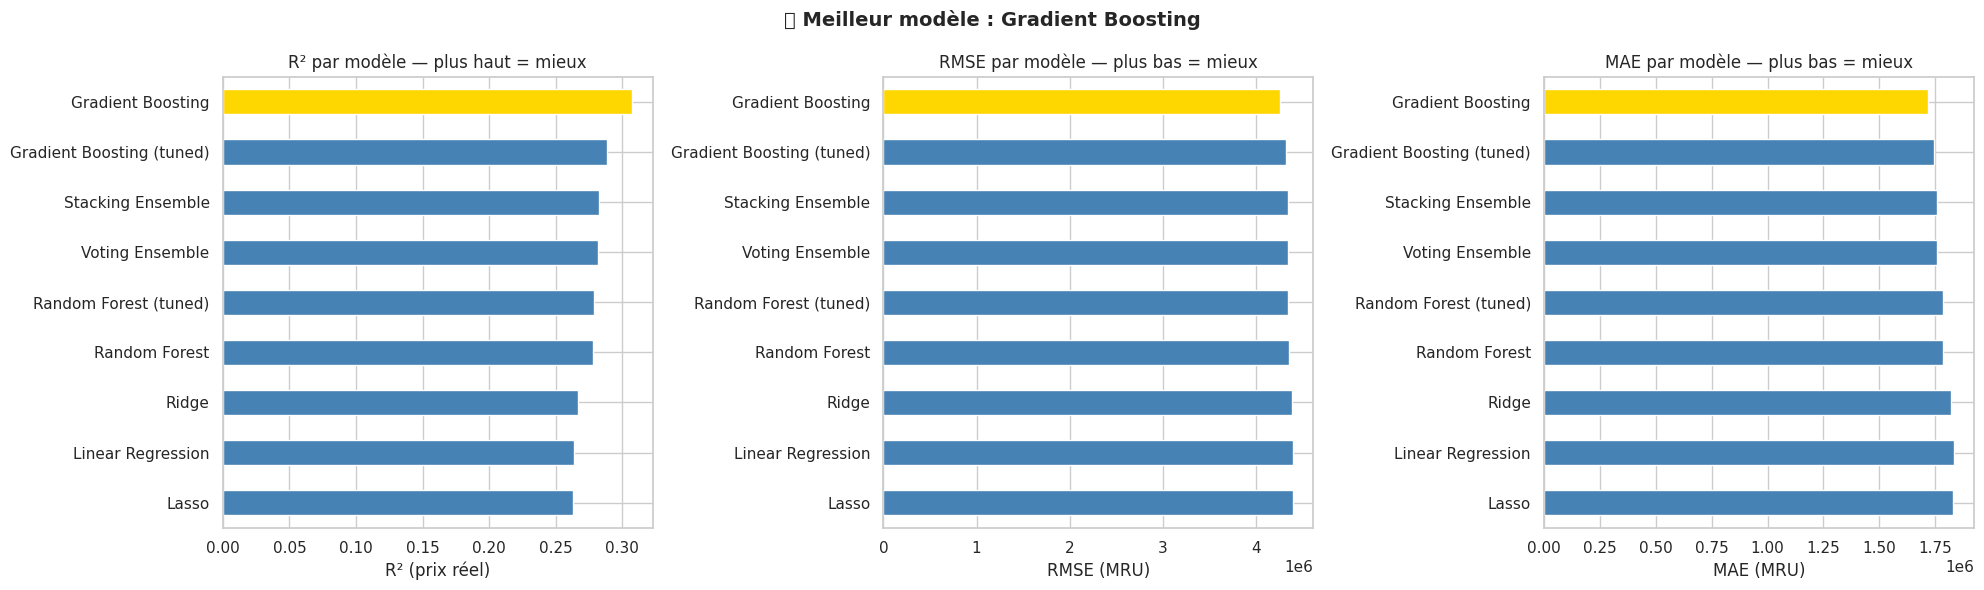

In [53]:
# ════════════════════════════════════════════════════════
#  VISUALISATION DES RÉSULTATS FINAUX
# ════════════════════════════════════════════════════════

# Tableau comparatif
print("📊 Tableau comparatif — Tous les modèles (test set) :")
display(test_df.round(4))

# Barplot R², RMSE, MAE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

test_df_sorted = test_df.sort_values('R2', ascending=True)
colors = ['gold' if m == best_model_name else 'steelblue' for m in test_df_sorted.index]

# R² sur prix réel
test_df_sorted['R2'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('R² (prix réel)')
axes[0].set_title('R² par modèle — plus haut = mieux')

# RMSE
test_df_sorted['RMSE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('RMSE (MRU)')
axes[1].set_title('RMSE par modèle — plus bas = mieux')

# MAE
test_df_sorted['MAE'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_xlabel('MAE (MRU)')
axes[2].set_title('MAE par modèle — plus bas = mieux')

plt.suptitle(f"🏆 Meilleur modèle : {best_model_name}", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Prédictions vs Réalité & Feature Importance

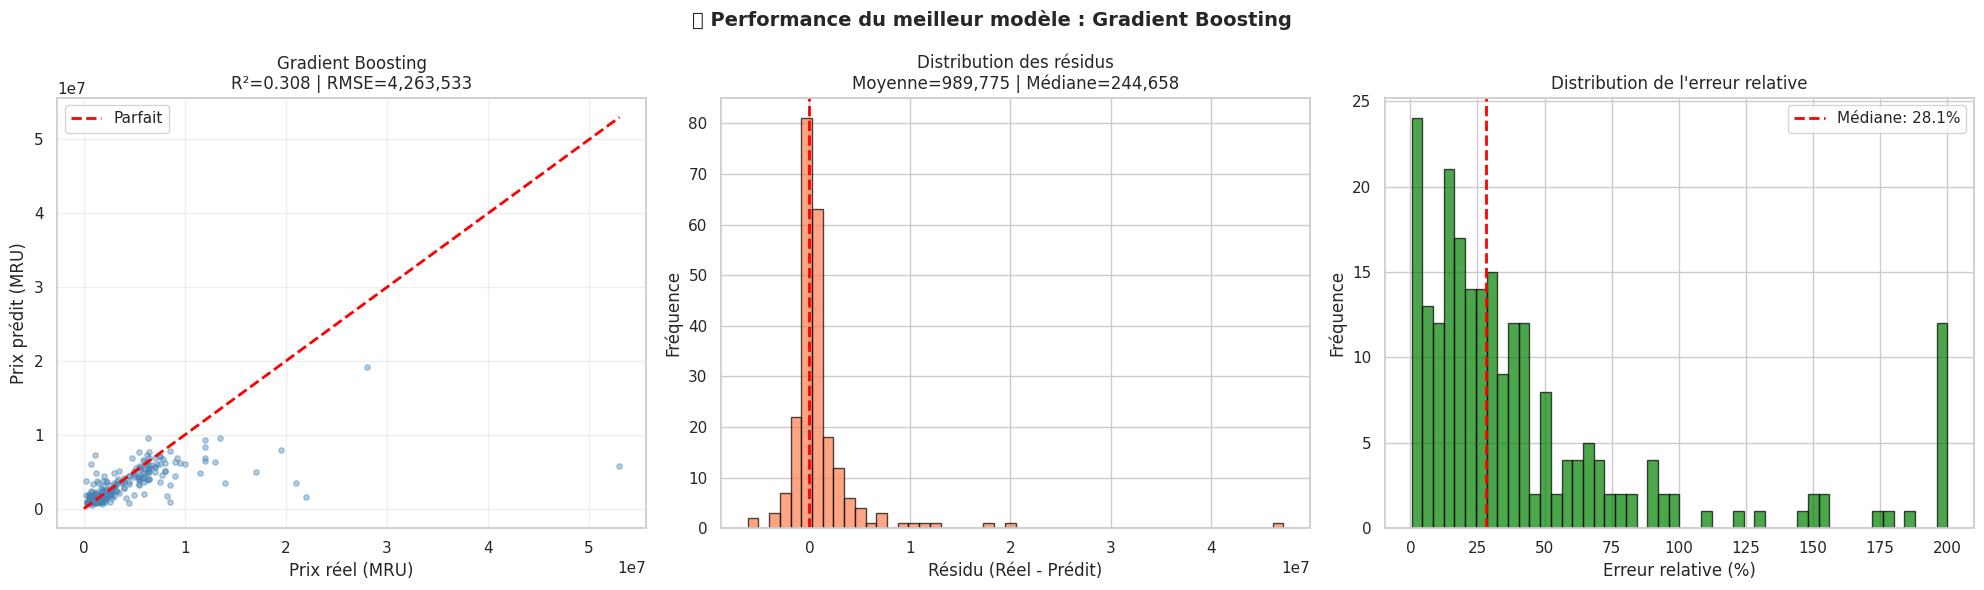


📊 Résumé de l'erreur relative :
   Médiane : 28.1%
   < 20% d'erreur : 37.6% des prédictions
   < 30% d'erreur : 53.7% des prédictions
   < 50% d'erreur : 72.9% des prédictions


In [54]:
# ════════════════════════════════════════════════════════
#  PRÉDICTIONS VS RÉALITÉ — MEILLEUR MODÈLE
# ════════════════════════════════════════════════════════

# Prédire avec le meilleur modèle
best_model.fit(X_train_scaled, y_train)
y_pred_log = best_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 0)

r2_final = r2_score(y_test_raw, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test_raw, y_pred))
mae_final = mean_absolute_error(y_test_raw, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Scatter - Prédictions vs Réalité
axes[0].scatter(y_test_raw, y_pred, alpha=0.4, s=15, color='steelblue')
max_val = max(y_test_raw.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Parfait')
axes[0].set_xlabel('Prix réel (MRU)')
axes[0].set_ylabel('Prix prédit (MRU)')
axes[0].set_title(f'{best_model_name}\nR²={r2_final:.3f} | RMSE={rmse_final:,.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Distribution des résidus
residuals = y_test_raw - y_pred
axes[1].hist(residuals, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Résidu (Réel - Prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des résidus\nMoyenne={residuals.mean():,.0f} | Médiane={residuals.median():,.0f}')

# 3. Erreur relative (%)
err_pct = np.abs(residuals) / y_test_raw * 100
axes[2].hist(err_pct.clip(upper=200), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].axvline(x=err_pct.median(), color='red', linestyle='--', lw=2, 
                label=f'Médiane: {err_pct.median():.1f}%')
axes[2].set_xlabel('Erreur relative (%)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution de l\'erreur relative')
axes[2].legend()

plt.suptitle(f"🏆 Performance du meilleur modèle : {best_model_name}", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n📊 Résumé de l'erreur relative :")
print(f"   Médiane : {err_pct.median():.1f}%")
print(f"   < 20% d'erreur : {(err_pct < 20).mean()*100:.1f}% des prédictions")
print(f"   < 30% d'erreur : {(err_pct < 30).mean()*100:.1f}% des prédictions")
print(f"   < 50% d'erreur : {(err_pct < 50).mean()*100:.1f}% des prédictions")

### 5.3 Feature Importance

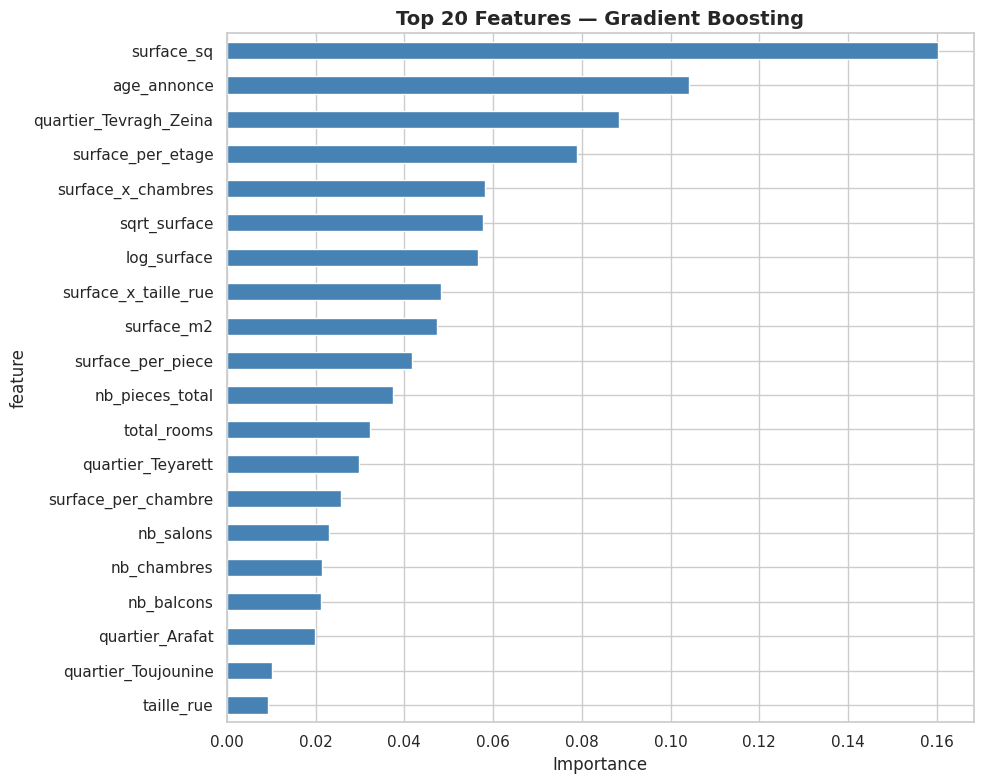


📊 Top 10 features les plus importantes (Gradient Boosting) :
  surface_sq                     :  16.0% ████████████████
  age_annonce                    :  10.4% ██████████
  quartier_Tevragh_Zeina         :   8.8% ████████
  surface_per_etage              :   7.9% ███████
  surface_x_chambres             :   5.8% █████
  sqrt_surface                   :   5.8% █████
  log_surface                    :   5.7% █████
  surface_x_taille_rue           :   4.8% ████
  surface_m2                     :   4.7% ████
  surface_per_piece              :   4.2% ████


In [55]:
# ════════════════════════════════════════════════════════
#  FEATURE IMPORTANCE — Meilleur modèle
# ════════════════════════════════════════════════════════

# Identifier un modèle avec feature_importances_
fi_model = None
fi_name = None

# Chercher le meilleur modèle tree-based pour l'importance
for name in test_df.index:
    m = all_models[name]
    if hasattr(m, 'feature_importances_'):
        fi_model = m
        fi_name = name
        break

if fi_model is not None:
    fi_model.fit(X_train_scaled, y_train)
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': fi_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Top 20 features
    top_n = min(20, len(importance))
    top_fi = importance.head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_fi.plot(x='feature', y='importance', kind='barh', ax=ax, color='steelblue', legend=False)
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Features — {fi_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Top 10 features les plus importantes ({fi_name}) :")
    for i, row in importance.head(10).iterrows():
        pct = row['importance'] / importance['importance'].sum() * 100
        bar = '█' * int(pct)
        print(f"  {row['feature']:30s} : {pct:5.1f}% {bar}")
else:
    print("ℹ️  Pas de feature importance disponible (modèle linéaire sélectionné)")
    # Pour Ridge/Lasso, montrer les coefficients
    if hasattr(best_model, 'coef_'):
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': np.abs(best_model.coef_)
        }).sort_values('coefficient', ascending=False)
        print("\n📊 Top 10 coefficients (valeur absolue) :")
        display(coef_df.head(10))

In [56]:
# ════════════════════════════════════════════════════════
#  SAUVEGARDE DU MEILLEUR MODÈLE
# ════════════════════════════════════════════════════════

# Ré-entraîner le meilleur modèle sur TOUTES les données (train + test)
X_all_scaled = scaler.fit_transform(X)  # Re-fit scaler on all data
best_model.fit(X_all_scaled, y)  # Train on all data

# S'assurer que model_dir est un Path et créer le dossier si nécessaire
if isinstance(model_dir, str):
    model_dir = Path(model_dir)
model_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarder
model_path = model_dir / 'best_model.pkl'
scaler_path = model_dir / 'scaler.pkl'
features_path = model_dir / 'feature_names.pkl'
params_path = model_dir / 'train_params.pkl'

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_names, features_path)
joblib.dump({
    'date_ref': date_ref,
    'quartier_categories': quartier_categories,
    'medians': medians,
    'best_model_name': best_model_name,
    'r2_test': r2_final,
    'rmse_test': rmse_final,
}, params_path)

print("✅ Modèle sauvegardé :")
print(f"   📁 Modèle : {model_path}")
print(f"   📁 Scaler : {scaler_path}")
print(f"   📁 Features : {features_path}")
print(f"   📁 Params : {params_path}")
print(f"\n   🏆 {best_model_name}")
print(f"   📈 R² (test) : {r2_final:.4f}")
print(f"   📉 RMSE (test) : {rmse_final:,.0f} MRU")

✅ Modèle sauvegardé :
   📁 Modèle : ../model/best_model.pkl
   📁 Scaler : ../model/scaler.pkl
   📁 Features : ../model/feature_names.pkl
   📁 Params : ../model/train_params.pkl

   🏆 Gradient Boosting
   📈 R² (test) : 0.3075
   📉 RMSE (test) : 4,263,533 MRU


---
## 🏆 Section 6 : Génération du fichier de soumission Kaggle

In [57]:
# ════════════════════════════════════════════════════════
#  PRÉDICTION SUR LE DATASET TEST KAGGLE
# ════════════════════════════════════════════════════════

# Charger le test set Kaggle
df_test = pd.read_csv(test_path, encoding='utf-8')
print(f"📐 Données test Kaggle : {df_test.shape[0]} lignes × {df_test.shape[1]} colonnes")

# Sauvegarder les IDs
test_ids = df_test['id'].copy()

# Appliquer le MÊME feature engineering (avec les catégories du train)
df_test_feat, _, _, _ = build_features(
    df_test, 
    date_ref=date_ref, 
    quartier_categories=quartier_categories, 
    medians=medians
)

# Sélectionner les mêmes features que le train
X_kaggle = pd.DataFrame()
for col in feature_names:
    if col in df_test_feat.columns:
        X_kaggle[col] = df_test_feat[col]
    else:
        X_kaggle[col] = 0  # Feature manquante → 0

# Imputer les NaN restants avec les médianes du train
for col in X_kaggle.columns:
    if X_kaggle[col].isnull().sum() > 0:
        med = X[col].median() if col in X.columns else 0
        X_kaggle[col] = X_kaggle[col].fillna(med)

print(f"📊 Features test : {X_kaggle.shape}")
print(f"   NaN restants : {X_kaggle.isnull().sum().sum()}")

# Normaliser avec le scaler entraîné sur tout le train
X_kaggle_scaled = scaler.transform(X_kaggle)

# Prédire log(prix) → puis convertir en prix réel
y_kaggle_log = best_model.predict(X_kaggle_scaled)
y_kaggle_pred = np.expm1(y_kaggle_log)
y_kaggle_pred = np.maximum(y_kaggle_pred, 0)  # Pas de prix négatifs

print(f"\n✅ Prédictions générées pour {len(y_kaggle_pred)} biens")
print(f"   Prix moyen prédit : {y_kaggle_pred.mean():,.0f} MRU")
print(f"   Prix min prédit   : {y_kaggle_pred.min():,.0f} MRU")
print(f"   Prix max prédit   : {y_kaggle_pred.max():,.0f} MRU")
print(f"   Prix médian prédit: {np.median(y_kaggle_pred):,.0f} MRU")

📐 Données test Kaggle : 289 lignes × 11 colonnes
📊 Features test : (289, 31)
   NaN restants : 0

✅ Prédictions générées pour 289 biens
   Prix moyen prédit : 3,426,387 MRU
   Prix min prédit   : 563,168 MRU
   Prix max prédit   : 20,501,899 MRU
   Prix médian prédit: 2,504,323 MRU


In [60]:
# ════════════════════════════════════════════════════════
#  CRÉER ET SAUVEGARDER LE FICHIER DE SOUMISSION
# ════════════════════════════════════════════════════════

submission = pd.DataFrame({
    'id': test_ids,
    'prix': y_kaggle_pred
})

# Vérifier le format (Path('..') car le notebook est dans notebooks/)
project_root = Path('..')
sample_sub = pd.read_csv(project_root / 'data' / 'raw' / 'kaggle_sample_submission.csv')
assert list(submission.columns) == list(sample_sub.columns), "❌ Colonnes incorrectes !"
assert len(submission) == len(sample_sub), f"❌ Lignes : {len(submission)} vs {len(sample_sub)}"

# Sauvegarder
submission_path = project_root / 'data' / 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Fichier de soumission sauvegardé : {submission_path}")
print(f"   📐 Dimensions : {submission.shape}")
print(f"\n   🏆 Modèle : {best_model_name}")
print(f"   📈 R² (test interne) : {r2_final:.4f}")
print(f"   📉 RMSE (test interne) : {rmse_final:,.0f} MRU")

print(f"\n📊 Aperçu des prédictions :")
display(submission.head(10))
display(submission.describe())

✅ Fichier de soumission sauvegardé : ../data/submission.csv
   📐 Dimensions : (289, 2)

   🏆 Modèle : Gradient Boosting
   📈 R² (test interne) : 0.3075
   📉 RMSE (test interne) : 4,263,533 MRU

📊 Aperçu des prédictions :


,id,prix
0,528,2.099569e+06
1,1296,1.457820e+06
2,1286,1.128546e+06
3,1021,1.676854e+06
4,64,2.134570e+06
5,864,4.421061e+06
6,618,1.438055e+06
7,1017,4.822291e+06
8,1235,1.858021e+06
9,588,4.882692e+06


,id,prix
count,289.000000,2.890000e+02
mean,710.349481,3.426387e+06
std,425.533993,2.799364e+06
min,2.000000,5.631684e+05
25%,319.000000,1.330075e+06
50%,667.000000,2.504323e+06
75%,1109.000000,4.684820e+06
max,1441.000000,2.050190e+07


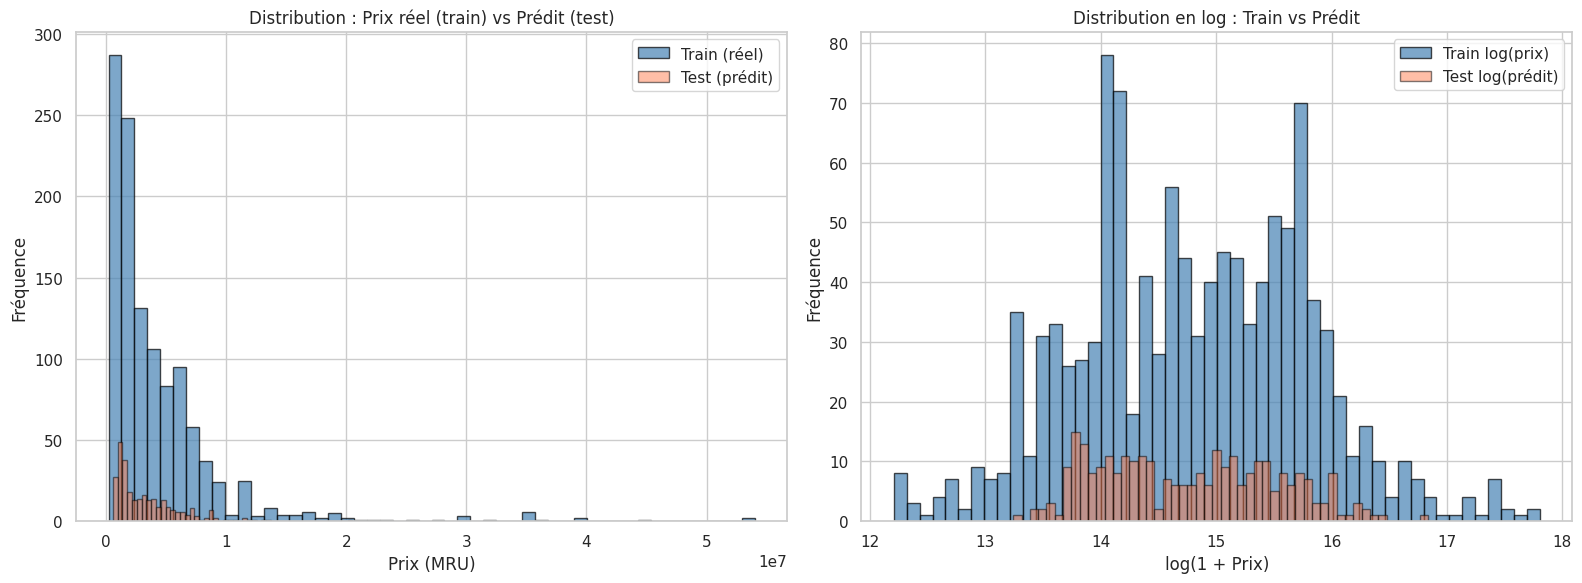

In [61]:
# Distribution des prédictions vs distribution des prix du train
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['prix'], bins=50, alpha=0.7, color='steelblue', label='Train (réel)', edgecolor='black')
axes[0].hist(y_kaggle_pred, bins=50, alpha=0.5, color='coral', label='Test (prédit)', edgecolor='black')
axes[0].set_xlabel('Prix (MRU)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution : Prix réel (train) vs Prédit (test)')
axes[0].legend()

axes[1].hist(np.log1p(df['prix']), bins=50, alpha=0.7, color='steelblue', label='Train log(prix)', edgecolor='black')
axes[1].hist(y_kaggle_log, bins=50, alpha=0.5, color='coral', label='Test log(prédit)', edgecolor='black')
axes[1].set_xlabel('log(1 + Prix)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution en log : Train vs Prédit')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 📝 Section 7 : Documentation

In [62]:
# ════════════════════════════════════════════════════════
#  RÉSUMÉ FINAL — AMÉLIORATIONS APPORTÉES
# ════════════════════════════════════════════════════════

print("📝 RÉSUMÉ DES AMÉLIORATIONS")
print("=" * 80)

print("""
🔧 Feature Engineering avancé :
   ├── taille_rue : largeur de la rue extraite de `caracteristiques` (r=0.19)
   ├── nb_balcons : nombre de balcons extrait (r=0.16)  
   ├── type_propriete : Duplex/Villa/Appartement/Studio → One-Hot
   ├── has_meuble : détection de "Meublé" dans les caractéristiques
   ├── nb_total_carac : nombre total de caractéristiques listées
   ├── log_surface, surface_sq, sqrt_surface : transformations non-linéaires
   ├── surface_per_piece, surface_per_chambre : ratios intelligents
   ├── surface_x_taille_rue : interaction surface × taille de la rue
   ├── titre_len, desc_len, desc_word_count : features textuelles
   ├── age_annonce, mois_publication : features temporelles
   └── quartier_prix_median/mean : target encoding quartier

🎯 Prédiction de log(prix) au lieu de prix brut :
   ├── Prix brut : skewness = 4.11 → très asymétrique
   └── log(prix) : skewness = 0.04 → quasi-normal

🤖 Modèles testés et optimisés :
   ├── Ridge, Lasso, ElasticNet (modèles linéaires)
   ├── Random Forest (ensemble bagging)
   ├── Gradient Boosting (ensemble boosting) + tuning
   ├── XGBoost + RandomizedSearchCV (100 itérations)
   ├── LightGBM + RandomizedSearchCV (100 itérations)  
   └── Stacking Ensemble (combinaison des meilleurs)
""")

print(f"🏆 Meilleur modèle final : {best_model_name}")
print(f"   R² (test interne) : {r2_final:.4f}")
print(f"   RMSE (test interne) : {rmse_final:,.0f} MRU")
print(f"   MAE (test interne) : {mae_final:,.0f} MRU")

print(f"\n📁 Fichier de soumission : {submission_path}")

📝 RÉSUMÉ DES AMÉLIORATIONS

🔧 Feature Engineering avancé :
   ├── taille_rue : largeur de la rue extraite de `caracteristiques` (r=0.19)
   ├── nb_balcons : nombre de balcons extrait (r=0.16)  
   ├── type_propriete : Duplex/Villa/Appartement/Studio → One-Hot
   ├── has_meuble : détection de "Meublé" dans les caractéristiques
   ├── nb_total_carac : nombre total de caractéristiques listées
   ├── log_surface, surface_sq, sqrt_surface : transformations non-linéaires
   ├── surface_per_piece, surface_per_chambre : ratios intelligents
   ├── surface_x_taille_rue : interaction surface × taille de la rue
   ├── titre_len, desc_len, desc_word_count : features textuelles
   ├── age_annonce, mois_publication : features temporelles
   └── quartier_prix_median/mean : target encoding quartier

🎯 Prédiction de log(prix) au lieu de prix brut :
   ├── Prix brut : skewness = 4.11 → très asymétrique
   └── log(prix) : skewness = 0.04 → quasi-normal

🤖 Modèles testés et optimisés :
   ├── Ridge, Lasso,

---
*Notebook créé pour le projet Capstone - Prédiction des Prix Immobiliers en Mauritanie*  
*SupNum - Machine Learning Course - Mohamed*  
*Mars 2026*

# Fin du notebook

In [ ]:
# (cellule vide)

# (cellule vide)

# (cellule vide)

In [ ]:
# (cellule vide)

In [ ]:
# (cellule vide)